
# Milestone 2

Nama : Christian Nathanael Pranata\
Class : RMT - 015\
Link Dashboard Tableau: https://public.tableau.com/views/P1M2_Christian_Pranata/Dashboard1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

## Business Objective

Tim analyst bertujuan untuk mengidentifikasi produk, brand, dan kategori sepatu Olaharga yang memberikan kontribusi revenue tertinggi berdasarkan data penjualan, sehingga perusahaan third party retailer dapat mengoptimalkan strategi penjualan quartal selanjutnya dan pemasaran pada produk unggulan untuk meningkatkan profit.

## Indentifikasi Masalah

Mendefinisikan pernyataan masalah menggunakan Kerangka Kerja SMART:

1. Specific (S): Perusahaan ingin mengidentifikasi faktor-faktor yang memengaruhi penjualan sepatu olahraga, seperti harga, rating, brand, dan kategori produk.

2. Measurable (M): Keberhasilan analisis diukur dengan Mengidentifikasi Top 5 produk/brand/kategori dengan kontribusi revenue tertinggi dan
Menemukan minimal 3 faktor utama yang berpengaruh signifikan terhadap revenue

3. Achievable (A): Melakukan Exploratory Data Analysis (EDA).

4. Relevant (R): Menentukan fokus produk unggulan dan Mengoptimalkan strategi pemasaran dan promosi.

5. Time-Bound (T): Hasil proses analisis ditargetkan selesai dalam waktu 1–2 minggu, mencakup tahap data cleaning, eksplorasi data, analisis, hingga penyusunan insight dan rekomendasi bisnis.

Pernyataan Masalah: Perusahaan bertujuan untuk mengidentifikasi faktor-faktor yang memengaruhi penjualan sepatu olahraga, seperti harga, rating, brand, dan kategori produk, melalui analisis data menggunakan exploratory data analysis (EDA). Keberhasilan diukur dengan mengidentifikasi lima produk atau brand dengan kontribusi revenue tertinggi serta menemukan minimal tiga faktor utama yang berpengaruh signifikan. Hasil analisis diharapkan dapat membantu dalam menentukan produk unggulan dan mengoptimalkan strategi pemasaran, dengan target penyelesaian dalam waktu satu hingga dua minggu.

### Breaking Down the Problem

**Main Problem:**  
Bagaimana cara mengidentifikasi produk unggulan yang menghasilkan profit tertinggi untuk mengembangkan strategi penjualan dan pemasaran untuk meningkatkan profit perusahaan?

Untuk memudahkan dalam analisis dan memecahkan masalah, perlu memahami detail dari permasalahan. Metode yang digunakan yakni 5W + 1H:
1. Brand produk apa yang menghasilkan revenue terbesar?
2. Category produk apa yang paling banyak dibeli?
3. Bagaimana Tren brand sepatu 5 tahun ke belakang? 
4. Sales channel apa yang paling sering diminati?
5. Apakah warna berpengaruh pada penjualan?
6. bagaimana Statistik Deskriptif revenue penjualan sepatu olahraga dalam 5 tahun terakhir?
7. Apakah ada perbedaan Revenue yang signifikan di setiap level customer income?

## Data Loading

In [1]:
import pandas as pd
import seaborn as sns
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('E:\HACKTIV8-CODA\p1-coda015-rmt-m2-christian2103\global_sports_footwear_sales.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\H'
<>:1: SyntaxWarning: invalid escape sequence '\H'
C:\Users\User\AppData\Local\Temp\ipykernel_4960\2240496401.py:1: SyntaxWarning: invalid escape sequence '\H'
  df = pd.read_csv('E:\HACKTIV8-CODA\p1-coda015-rmt-m2-christian2103\global_sports_footwear_sales.csv')


,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0


In [202]:
df.shape

(30000, 18)

In [4]:
df.describe()

,size,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,customer_rating
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,8.500867,139.634633,13.332167,121.029035,2.500200,302.714948,4.001543
std,1.710896,46.062549,9.864198,42.511586,1.121149,179.149272,0.577546
min,6.000000,60.000000,0.000000,42.000000,1.000000,42.000000,3.000000
25%,7.000000,100.000000,5.000000,85.000000,1.000000,156.750000,3.500000
50%,9.000000,140.000000,10.000000,119.200000,3.000000,268.200000,4.000000
75%,10.000000,180.000000,20.000000,153.600000,4.000000,414.000000,4.500000
max,11.000000,219.000000,30.000000,219.000000,4.000000,876.000000,5.000000


Insight:
- Produk dijual pada kisaran harga menengah ($100–$180).

- Penjualan rata-rata per transaksi relatif kecil (1–4 unit) konsumen yang beli bersifat individu.

- Revenue memiliki variasi yang cukup tinggi, menunjukkan adanya produk dengan performa sangat unggul dibandingkan lainnya.

## Data Cleaning

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               30000 non-null  str           
 1   order_date             30000 non-null  datetime64[us]
 2   brand                  30000 non-null  str           
 3   model_name             30000 non-null  str           
 4   category               30000 non-null  str           
 5   gender                 30000 non-null  str           
 6   size                   30000 non-null  int64         
 7   color                  30000 non-null  str           
 8   base_price_usd         30000 non-null  int64         
 9   discount_percent       30000 non-null  int64         
 10  final_price_usd        30000 non-null  float64       
 11  units_sold             30000 non-null  int64         
 12  revenue_usd            30000 non-null  float64       
 13  payment_meth

1. Total ada 30.000 row dan 18 Column yang berisi data 
2. Semua data tidak ada missing value
3. Order date perlu di ganti

In [200]:
df.duplicated().sum()

np.int64(0)

(Tidak ada data duplicated )

In [55]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [56]:
df['year'] = df['order_date'].dt.year

In [57]:
df['month'] = df['order_date'].dt.month

## EDA

#### Q1: Brand produk apa yang menghasilkan revenue terbesar?

In [7]:
total_revenue = df.groupby(['brand'])['revenue_usd'].sum().reset_index()

In [18]:
total_revenue.sort_values('revenue_usd', ascending=False)

,brand,revenue_usd
0,ASICS,1561462.50
3,Nike,1524582.10
2,New Balance,1511401.50
4,Puma,1499094.90
5,Reebok,1498640.90
1,Adidas,1486266.55


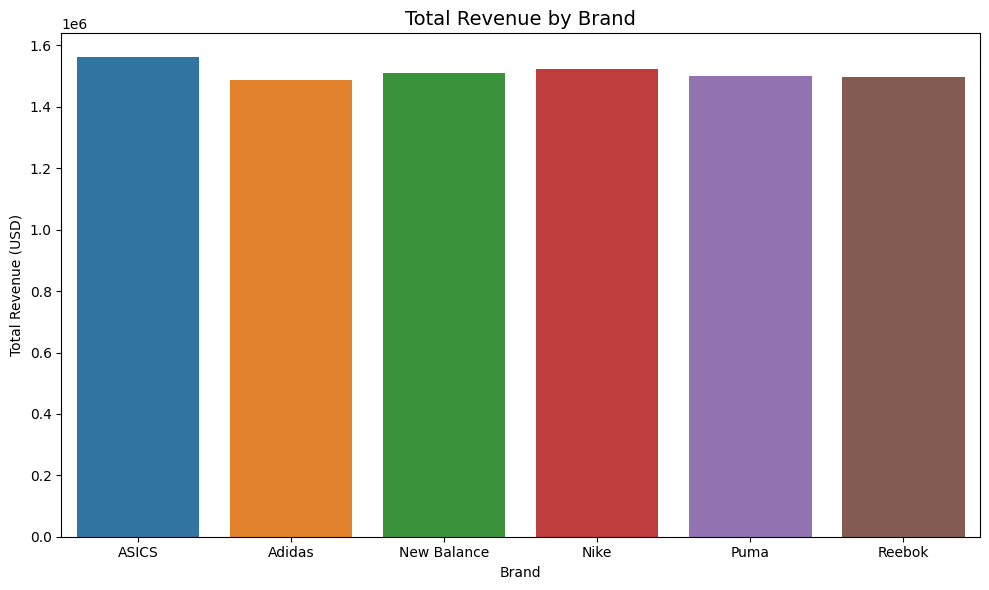

In [139]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=total_revenue,
    x='brand',
    y='revenue_usd',
    hue='brand'
)

plt.title('Total Revenue by Brand', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Total Revenue (USD)')

plt.tight_layout()
plt.show()

- dari data ini ASICS merupakan Brand dengan revenue tertinggi selama periode analisis.

- Perbedaan revenue dari antara brand ini rata rata tidak begitu besar yang ini menunjukkan persaingan pasar yang sangat kompetitif.
\
\
dari chart ini ASICS bisa di gunakan sebagai benchmark performa,  strategi marketing dan optimasi penjualan.

#### Q2: Category produk apa yang paling banyak dibeli?

In [196]:
category_unit_solds = df.groupby('category')['units_sold'].sum().reset_index()

In [197]:
category_unit_solds.sort_values('units_sold', ascending=False)

,category,units_sold
0,Basketball,15160
4,Training,15142
2,Lifestyle,15129
3,Running,14928
1,Gym,14647


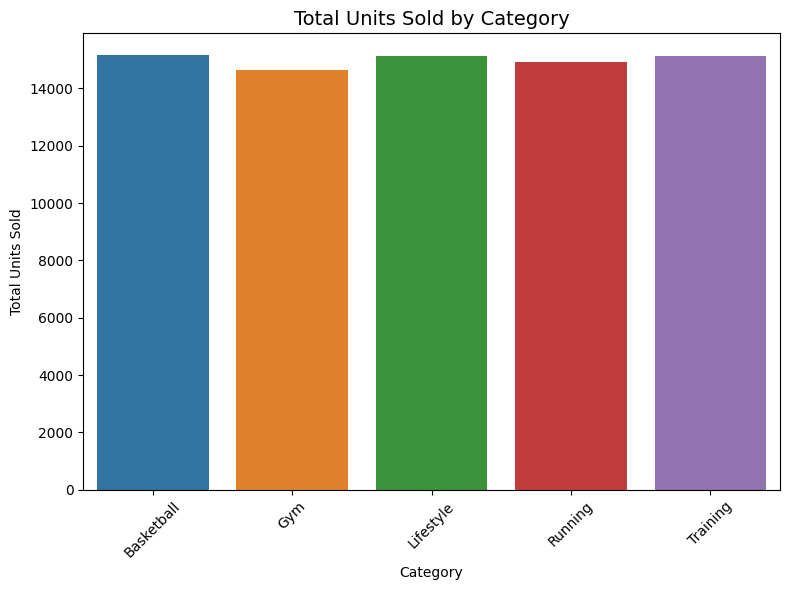

In [198]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=category_unit_solds,
    x='category',
    y='units_sold',
    hue='category'
)

plt.title('Total Units Sold by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- Basketball menjadi kategori dengan penjualan unit tertinggi.

- Dari data ini selisih antar kategori sangat kecil yang artinya permintaan pasar relatif merata.

Strategi promosi dapat difokuskan pada Basketball dan Training sebagai kategori unggulan, namun tetap menjaga sales produk lainnya karena demand cukup stabil.

#### Q3: Sales channel apa yang paling sering diminati?

In [25]:
sales_channel_count = df['sales_channel'].value_counts().reset_index()

In [ ]:
sales_channel_count

,sales_channel,count
0,Retail Store,15009
1,Online,14991


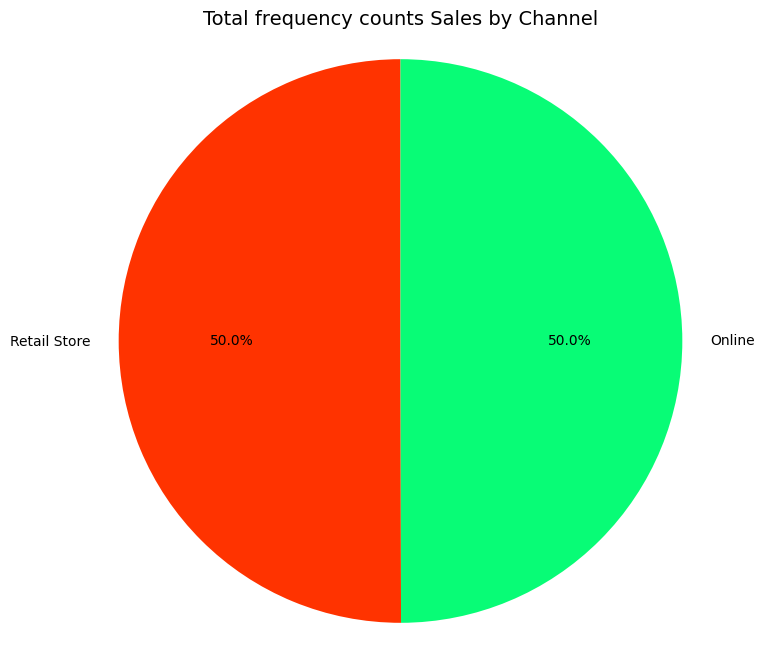

In [129]:
plt.figure(figsize=(8, 8))
plt.pie(sales_channel_count['count'], labels=sales_channel_count['sales_channel'], autopct='%1.1f%%', startangle=90, colors=["#ff3300ff","#08fc76"])
plt.title('Total frequency counts Sales by Channel', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is drawn as a circle.
plt.show()

- Penjualan hampir seimbang antara Retail dan Online.\
Perusahaan harus mempertahankan Sales kedua channel, dan Potensi peningkatan bisa difokuskan pada optimalisasi digital marketing untuk mendorong Online sedikit lebih unggul.

#### Q4: Bagaimana Tren brand sepatu 5 tahun ke belakang?

In [167]:
df_five_year = df[(df['year'] >= 2021) & (df['year'] <= 2025)]

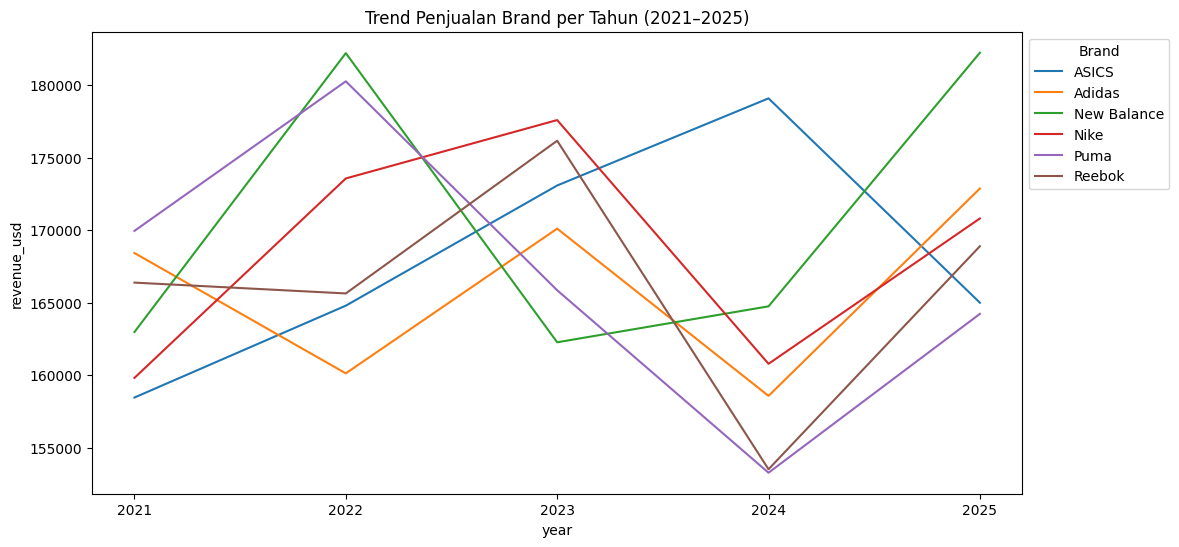

In [168]:
trend = df_five_year.groupby(['year', 'brand'])['revenue_usd'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=trend, x='year', y='revenue_usd', hue='brand')
plt.legend(title='Brand', bbox_to_anchor=(1, 1), loc='upper left')
plt.xticks([2021, 2022, 2023, 2024, 2025])
plt.title("Trend Penjualan Brand per Tahun (2021–2025)")
plt.show()

- Tahun 2024 terlihat sebagai tahun penurunan hampir semua brand → kemungkinan ada faktor seperti ekonomi, daya beli atau pandemi.

- Tahun 2025 menunjukkan pasar mengalami peningkatan kembali.

- dari data ini New Balance memiliki pertumbuhan paling tinggi di 2025.

#### Q5: Warna apa yang paling populer pada penjualan?

In [158]:
color_count = df.groupby('color')['units_sold'].sum().reset_index()
color_count.sort_values('units_sold', ascending=False)

,color,units_sold
2,Grey,15134
1,Blue,15100
3,Red,15097
4,White,14907
0,Black,14768


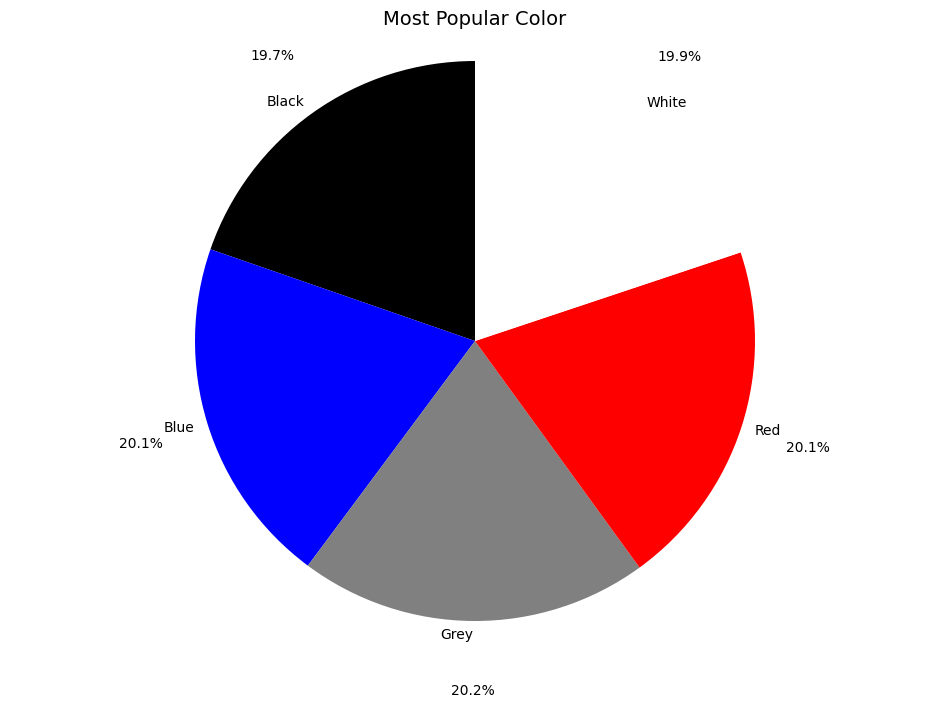

In [191]:
plt.figure(figsize=(12, 8))
plt.pie(
color_count['units_sold'], 
labels=color_count['color'], 
autopct='%1.1f%%',
startangle=90,
colors=color_count['color'],
pctdistance=1.25, 
labeldistance=1.05
)
plt.title('Most Popular Color', fontsize=14)
plt.axis('equal') 
plt.show()

- Grey menjadi warna paling populer.
- Rata-rata dari setiap warna memiliki penjualan unit yang sama


#### Q6: Bagaimana Statistik Deskriptif revenue penjualan sepatu olahraga dalam 5 tahun terakhir?

In [170]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating,year,month
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6,2021,1
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9,2026,10
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0,2023,11
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4,2026,8
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0,2019,11


In [179]:
print('Average Revenue:',df_five_year['revenue_usd'].mean())
print('Median Revenue:', df_five_year['revenue_usd'].median())
print('Standar Deviasi Revenue:',df_five_year['revenue_usd'].std())
print('Skewness:', df_five_year['revenue_usd'].skew())
print('kurtosis:', df_five_year['revenue_usd'].kurtosis())

std = df['revenue_usd'].std()
N = len(df_five_year)
low, up = stats.norm.interval(0.95,loc=df['revenue_usd'].mean(),scale=std/np.sqrt(N))
print('Lower Limit:',low)
print('Upper Limit:',up)

Average Revenue: 302.5127780449682
Median Revenue: 267.75
Standar Deviasi Revenue: 179.5131849528241
Skewness: 0.7812986475756001
kurtosis: -0.09763662971437226
Lower Limit: 299.99246775664574
Upper Limit: 305.4374289100209


1. Mean Revenue (302.51)\
Dari rata-rata yang ada revenue per transaksi selama 5 tahun terakhir sekitar 302.51 USD.
2. Median Revenue (267.75) \
Dari median-nya menunjukkan bahwa separuh dari transaksi memiliki total di bawah 267.75 USD. ini menunjukan Ada beberapa transaksi dengan revenue tinggi yang menaikkan rata-rata.
3. Standar Deviasi Revenue (179.51)\
penyebaran data revenue antar transaksi cukup Besar Rata-rata jarak transaksi dari mean adalah sekitar 179 USD.
4. Skewness (0.78129)\
Skew 0.781 yang lebih besar dari 0 menunjukan Distribusi revenue miring ke kanan, terdapat beberapa transaksi dengan revenue tinggi.
5. Kurtosis (-0.097) \
Kurtosis -0.097 menunjukan Distribusi penjualan mendekati normal dan tidak memiliki outlier yang ekstrem.
6. Confidence interval\
Dengan tingkat kepercayaan 95%, rata-rata revenue kira kira berada di antara 299.99 USD hingga 305.44 USD.


#### Q7: Apakah ada perbedaan Revenue yang signifikan di setiap level customer income?

##### ANOVA
* Hipotesis Nol (H0): Tidak ada perbedaan Revenue yang signifikan di setiap level customer income.
* Hipotesis Alternatif (H1): Ada perbedaan Revenue yang signifikan di setiap level customer income.

In [204]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0


In [205]:
df['customer_income_level'].unique()

<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

In [206]:
low = df['revenue_usd'][(df['customer_income_level']=='Low') | (df['customer_income_level']=='low')]
medium = df['revenue_usd'][df['customer_income_level']=='Medium']
high = df['revenue_usd'][df['customer_income_level']=='High']

In [207]:
print(f'Average Revenue of Low Group: {low.mean():.2f}')
print(f'Average Revenue of Medium Group: {medium.mean():.2f}')
print(f'Average Revenue of High Group: {high.mean():.2f}')

Average Revenue of Low Group: 305.77
Average Revenue of Medium Group: 300.40
Average Revenue of High Group: 302.00


In [208]:
res = stats.f_oneway(low, medium, high)
print('P-value:',res.pvalue)

P-value: 0.09404691177846015


P-value lebih dari 0.05, artinya HO di terima, artinya tidak ada perbedaan yang signifikan di setiap level customer income.

di setiap level customer, customer membeli sepatu dengan quantity yang menghasilkan revenue $300 - $305 per transaksinya

## Kesimpulan

Insight yang bisa di dapat dari Analysist ini:
1. Brand disini memiliki pengaruh signifikan terhadap revenue karena terdapat perbedaan performa antar brand, meskipun gap-nya tidak ekstrem. ASICS menunjukkan performa paling konsisten dan stabil dalam periode 5 tahun.

2. Kategori produk berpengaruh terhadap volume penjualan. Permintaan relatif merata, namun Basketball memiliki keunggulan kompetitif tipis sehingga berpotensi menjadi kategori fokus.

3. Channel distribusi bukan faktor pembeda utama karena kontribusinya hampir sama. Tetapi strategi omnichannel menjadi faktor penting dalam menjaga stabilitas revenue.

4. Penurunan serentak di 2024 mengindikasikan kemungkinan faktor eksternal seperti daya beli atau ekonomi. 

5. Penjualan terlihat meningkat kembali di 2025 dan ini dapat menjadi momentum untuk ekspansi di 2026.

6. Preferensi warna memengaruhi volume penjualan, meskipun pengaruhnya tidak terlalu besar karena selisih unit antar warna relatif kecil namun warna Grey menjadi warna produk terpopuler dari seluruh periode.

Dari hasil analisis ini bisa dilihat bahwa ada faktor-faktor yang berpengaruh terhadap Revenue penjualan seperti: 
- Brand
- Kategori Produk 
- Trend
- Warna cukup berpengaruh walau tidak terlalu significan

Berdasarkan hasil dari Exploratory Data Analysis (EDA) kami menyimpulkan bahwa faktor-faktor utama yang memengaruhi penjualan sepatu olahraga adalah brand, kategori produk, dan tren waktu. dari brand ASICS menjadi brand dengan kontribusi revenue tertinggi, sementara kategori Basketball memiliki volume penjualan terbesar. Penjualan melalui retail dan online menunjukkan kontribusi yang hampir seimbang.

Selain itu, preferensi warna juga berpengaruh terhadap penjualan, dengan warna netral seperti Grey dan Blue lebih diminati pasar. Lalu dari hasil ini trend juga kami menemukan adanya penurunan signifikan pada tahun 2024 yang memengaruhi hampir seluruh brand, yang ini mengindikasikan adanya faktor eksternal yang perlu dianalisis lebih lanjut. 

Dengan demikian, perusahaan dapat memfokuskan strategi pada:

- Penguatan brand dengan performa stabil

- Optimalisasi kategori unggulan semua periode (Basketball & Training) dan kategori Lifestyle yang mungkin bisa di pertimbangkan karena Lifestyle masuk kategori ungguluan ke 2 di 2025

- Penyesuaian strategi terhadap tren pasar tahunan.